# ==========================================================
# 1. Подготовка окружения
# ==========================================================

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Нет GPU")

drive_dataset = "/content/drive/MyDrive/Tomato_Project/dataset/Tomato-Leaf-Disease-Detection-6"
local_dataset = "/content/Tomato-Leaf-Disease-Detection-6"

if not os.path.exists(local_dataset):
    print("Копирую датасет на локальный диск Colab...")
    shutil.copytree(drive_dataset, local_dataset)
    print("✅ Датасет скопирован.")
else:
    print("✅ Датасет уже существует.")

Mounted at /content/drive
GPU: Tesla T4
Копирую датасет на локальный диск Colab...
✅ Датасет скопирован.


In [ ]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.6 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Yo2osvNu696JobVtAYu6")
project = rf.workspace("personal-enkcf").project("tomato-leaf-disease-detection-gyozv")
version = project.version(6)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Tomato-Leaf-Disease-Detection-6 in yolov8:: 100%|██████████| 21200/21200 [00:06<00:00, 3220.50it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from pathlib import Path

train_images = len(list(Path("/content/Tomato-Leaf-Disease-Detection-6/train/images").glob("*")))
val_images = len(list(Path("/content/Tomato-Leaf-Disease-Detection-6/valid/images").glob("*")))
test_images = len(list(Path("/content/Tomato-Leaf-Disease-Detection-6/test/images").glob("*")))

print(f"Train: {train_images}")
print(f"Validation: {val_images}")
print(f"Test: {test_images}")
print(f"Total: {train_images + val_images + test_images}")

Train: 9249
Validation: 896
Test: 449
Total: 10594


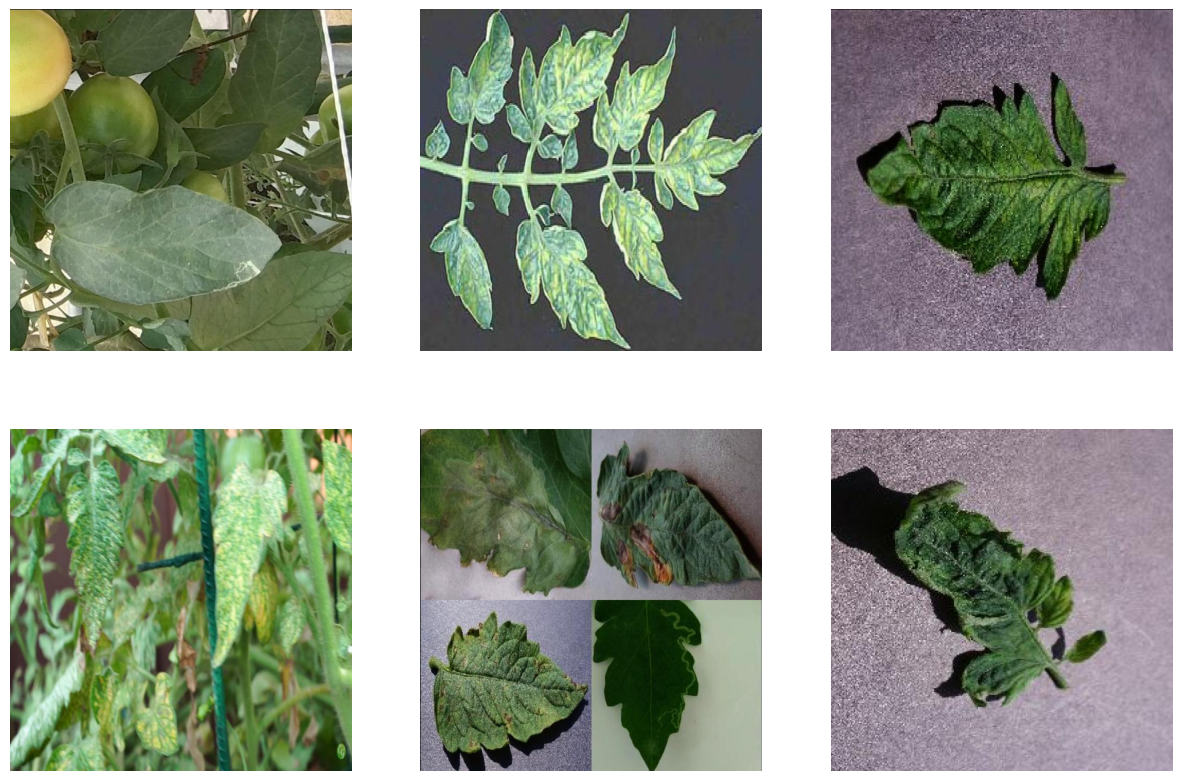

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import random

image_paths = list(Path("/content/Tomato-Leaf-Disease-Detection-6/train/images").glob("*"))

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(random.sample(image_paths, 6)):
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
import ultralytics
from ultralytics import YOLO

print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.84


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/Tomato-Leaf-Disease-Detection-6/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    project="results",
    name="YOLOv8_Tomato"
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Tomato-Leaf-Disease-Detection-6/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_Tomato, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp -r /content/runs /content/drive/MyDrive/

# ============================================
# YOLOv5
# ============================================

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

!pip install -qr requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 18406, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 18406 (delta 52), reused 25 (delta 24), pack-reused 18321 (from 3)
Receiving objects: 100% (18406/18406), 17.52 MiB | 27.26 MiB/s, done.
Resolving deltas: 100% (12500/12500), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 13.0 MB/s eta 0:00:00


In [ ]:
import yaml

yaml_path = "/content/yolov5/Tomato-Leaf-Disease-Detection-6/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data["train"] = "/content/yolov5/Tomato-Leaf-Disease-Detection-6/train/images"
data["val"] = "/content/yolov5/Tomato-Leaf-Disease-Detection-6/valid/images"
data["test"] = "/content/yolov5/Tomato-Leaf-Disease-Detection-6/test/images"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("✅ data.yaml обновлен")

✅ data.yaml обновлен


In [ ]:
!pip uninstall -y wandb

Found existing installation: wandb 0.28.0
Uninstalling wandb-0.28.0:
  Successfully uninstalled wandb-0.28.0


In [ ]:
!python /content/yolov5/train.py \
--img 640 \
--batch 16 \
--epochs 20 \
--data /content/yolov5/Tomato-Leaf-Disease-Detection-6/data.yaml \
--weights yolov5s.pt \
--project results \
--name YOLOv5_Tomato

train: weights=yolov5s.pt, cfg=, data=/content/yolov5/Tomato-Leaf-Disease-Detection-6/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=20, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=results, name=YOLOv5_Tomato, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_console=False, ndjson_file=False
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-508-g999e7b66 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, w

============================================
# **Faster R-CNN**
============================================

In [ ]:
!find "/content/drive/MyDrive" -name "*.zip"

/content/drive/MyDrive/Tomato_Project/Tomato Leaf Disease Detection.v6i.coco.zip


In [ ]:
!unzip -q "/content/drive/MyDrive/Tomato_Project/Tomato Leaf Disease Detection.v6i.coco.zip" -d /content/Tomato_COCO

In [ ]:
!find /content/Tomato_COCO -name "*.json"

/content/Tomato_COCO/valid/_annotations.coco.json
/content/Tomato_COCO/train/_annotations.coco.json
/content/Tomato_COCO/test/_annotations.coco.json


In [5]:
!pip install -q pycocotools

In [6]:
import os
import torch
import torchvision

from PIL import Image
from pycocotools.coco import COCO

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

AttributeError: module 'sympy' has no attribute 'printing'

In [7]:
class TomatoCOCODataset(Dataset):
    def __init__(self, root, annotation):
        self.root = root
        self.coco = COCO(annotation)
        self.ids = []
        for img_id in self.coco.imgs.keys():
            ann_ids = self.coco.getAnnIds(imgIds=img_id)
            if len(ann_ids) > 0:
                self.ids.append(img_id)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        img_info = self.coco.loadImgs(image_id)[0]
        path = os.path.join(self.root, img_info["file_name"])
        image = Image.open(path).convert("RGB")
        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)
        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id])
        }
        image = F.to_tensor(image)
        return image, target

NameError: name 'Dataset' is not defined

In [8]:
train_dataset = TomatoCOCODataset(
    "/content/Tomato_COCO/train",
    "/content/Tomato_COCO/train/_annotations.coco.json"
)

valid_dataset = TomatoCOCODataset(
    "/content/Tomato_COCO/valid",
    "/content/Tomato_COCO/valid/_annotations.coco.json"
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

empty = 0

for _, target in train_dataset:
    if len(target["boxes"]) == 0:
        empty += 1

print("Пустых изображений:", empty)

NameError: name 'TomatoCOCODataset' is not defined

In [9]:
import torchvision
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
num_classes = 10
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
import torch.optim as optim
optimizer = optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)
print(device)
images, targets = next(iter(train_loader))
images = [img.to(device) for img in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
model.train()
loss_dict = model(images, targets)

print(loss_dict)



AttributeError: module 'sympy' has no attribute 'printing'

In [ ]:
import os
import torch
from tqdm import tqdm

save_dir = "/content/drive/MyDrive/Tomato_Project/FasterRCNN"
os.makedirs(save_dir, exist_ok=True)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    epoch_loss /= len(train_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}")

    # Сохраняем модель после каждой эпохи
    torch.save(
        model.state_dict(),
        os.path.join(save_dir, f"epoch_{epoch+1}.pth")
    )

    print(f"Модель сохранена: epoch_{epoch+1}.pth")

# Финальное сохранение
torch.save(
    model.state_dict(),
    os.path.join(save_dir, "FasterRCNN_final.pth")
)

print("Обучение завершено.")
print("Финальная модель сохранена.")


Epoch 1/3: 100%|██████████| 4623/4623 [34:34<00:00,  2.23it/s]


Epoch 1/3 | Loss: 0.2792
Модель сохранена: epoch_1.pth


Epoch 2/3: 100%|██████████| 4623/4623 [34:43<00:00,  2.22it/s]


Epoch 2/3 | Loss: 0.2089
Модель сохранена: epoch_2.pth


Epoch 3/3: 100%|██████████| 4623/4623 [34:43<00:00,  2.22it/s]


Epoch 3/3 | Loss: 0.1853
Модель сохранена: epoch_3.pth
Обучение завершено.
Финальная модель сохранена.


In [10]:
import torch
import torchvision

device = torch.device("cpu")

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

num_classes = 10
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

AttributeError: module 'sympy' has no attribute 'printing'

In [3]:
import torch

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = box1_area + box2_area - inter_area

    return inter_area / union if union > 0 else 0


model.eval()

TP = 0
FP = 0
FN = 0

iou_threshold = 0.5

with torch.no_grad():
    for images, targets in valid_loader:
        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(outputs)):
            pred_boxes = outputs[i]["boxes"].cpu()
            gt_boxes = targets[i]["boxes"]

            matched = []

            for pred_box in pred_boxes:
                best_iou = 0
                best_gt_idx = -1

                for j, gt_box in enumerate(gt_boxes):
                    if j in matched:
                        continue

                    score = iou(pred_box.tolist(), gt_box.tolist())

                    if score > best_iou:
                        best_iou = score
                        best_gt_idx = j

                if best_iou >= iou_threshold:
                    TP += 1
                    matched.append(best_gt_idx)
                else:
                    FP += 1

            FN += (len(gt_boxes) - len(matched))

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)

print("Precision:", precision)
print("Recall:", recall)

NameError: name 'model' is not defined

In [ ]:
!ls /content/Tomato_COCO

README.dataset.txt  README.roboflow.txt  test  train  valid


SSD

In [ ]:
import torch
import torchvision

from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection import SSD300_VGG16_Weights

In [ ]:
num_classes = 10  # 9 классов + фон

from torchvision.models.detection import ssd300_vgg16

model = ssd300_vgg16(
    weights=None,
    num_classes=10
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("SSD загружена!")

ValueError: The parameter 'num_classes' expected value 91 but got 10 instead.

In [ ]:
import torchvision

print(torchvision.__version__)

0.26.0+cu128


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005
)

In [ ]:
import os

save_dir = "/content/drive/MyDrive/SSD_Tomato"

os.makedirs(save_dir, exist_ok=True)